In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import time
import logging
import os
import warnings
import itertools
from datetime import datetime, timedelta
from functools import partial
from pathlib import Path
from optimization_engines import (
    equal_weights_baseline, 
    genetic_algorithm_qubo, 
    scipy_slsqp_qubo, 
    riskfolio_qubo,
    dwave_cqm_qubo,
)

# Load D-Wave API token from .env file
from dotenv import load_dotenv
load_dotenv()

SEED = 12
np.random.seed(SEED)
msg_level = logging.INFO
# Suppress all RuntimeWarnings
warnings.filterwarnings("ignore", category=RuntimeWarning)

## Pareto Portfolio Optimization using D-Wave Quantum Solver

This notebook implements Pareto frontier optimization using D-Wave's CQM solver. The optimization explores different risk-return tradeoffs by varying the risk_level parameter.

In [22]:
# Create a logger
logger = logging.getLogger("inspect_results_logger")
logger.setLevel(msg_level)  # Set the level for this logger

### Path definition

In [23]:
benchmark_path = '../../data/benchmark_gspc.pkl'
source_path = '../../data/stocks_adjclose.pkl'
source_path_extended = '../../data/etfs_close.pkl'

### Data loading

Ticker,ds,^GSPC
0,2011-01-03,1271.869995
1,2011-01-04,1270.199951
2,2011-01-05,1276.560059
3,2011-01-06,1273.849976
4,2011-01-07,1271.500000


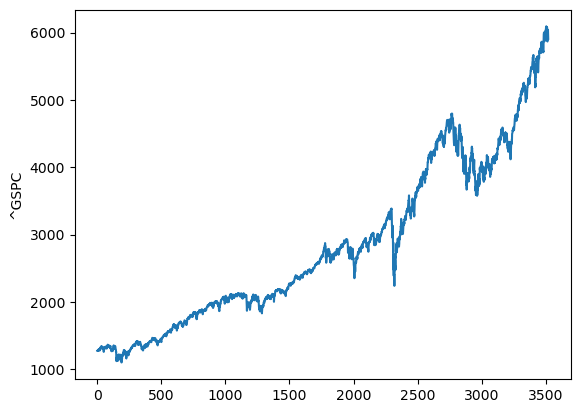

In [24]:
benchmark = pd.read_pickle(benchmark_path)
sns.lineplot(benchmark['^GSPC'])
benchmark.head()

In [25]:
source = pd.read_pickle(source_path)
print(source.shape)
# Check if any row contains at least one NaN
#print(source_wide.isnull().any(axis=1))
# Check if any value in the DataFrame is null
has_any_nan = source.isnull().values.any()
print("Any NaN in source_wide:", has_any_nan)
source.head()

(3522, 439)
Any NaN in source_wide: False


Ticker,A,AAPL,ABT,ACGL,ACN,ADBE,ADI,ADM,ADP,ADSK,...,WRB,WST,WTW,WY,WYNN,XEL,XOM,YUM,ZBH,ZBRA
ds,,,,,,,,,,,,,,,,,,,,,
2011-01-03,26.781836,9.917951,16.942663,9.349445,37.585785,31.290001,27.436106,20.712511,29.848969,39.270000,...,6.112024,18.971697,71.104691,11.828708,76.192101,14.700940,43.098133,26.977388,47.841393,38.200001
2011-01-04,26.532440,9.969709,17.102097,9.291334,37.338249,31.510000,27.125227,20.698887,29.741137,38.529999,...,6.072278,18.631702,69.911537,11.702991,78.568939,14.763333,43.300457,26.565216,47.206047,37.840000
2011-01-05,26.474880,10.051261,17.102097,9.305071,37.346004,32.220001,27.183071,20.794275,30.216925,41.240002,...,6.045782,18.713308,70.882263,12.068158,79.582596,14.675976,43.184826,26.691620,47.240875,37.799999
2011-01-06,26.526041,10.043136,17.066668,9.179339,37.485237,32.270000,27.334898,21.591436,30.451658,41.259998,...,5.977333,18.577297,71.084503,11.984348,80.162842,14.663502,43.462337,26.878460,45.778728,37.480000
2011-01-07,26.615564,10.115060,17.137522,9.109608,37.547104,32.040001,27.175838,21.768579,30.521458,40.759998,...,5.939793,18.486635,70.963158,12.313586,83.001091,14.794533,43.699345,27.213682,45.770027,37.599998


In [26]:
def portfolio_stats(weights, data):
    logger.info("=== portfolio_stats START ===")
    logger.info(f"Input weights shape: {np.array(weights).shape}")
    logger.info(f"Input data shape: {data.shape}")
    
    weights = np.array(weights)
    logger.info("Calculating log returns...")
    returns = np.log(data) - np.log(data.shift(1)) # log return to minimize fp error
    logger.info(f"Log returns calculated, shape: {returns.shape}")
    
    # CONSISTENT: Always use log returns, never pct_change()
    logger.info("Calculating portfolio return...")
    port_return = np.sum(returns.mean() * weights) 
    logger.info(f"Portfolio return: {port_return}")
    
    logger.info("Calculating portfolio volatility...")
    port_vol = np.sqrt(np.dot(weights.T, np.dot(returns.cov() , weights)))
    logger.info(f"Portfolio volatility: {port_vol}")
    
    logger.info("=== portfolio_stats END ===")
    return port_return, port_vol

### Data generator

Data generator to instantiate blocks on demand

In [27]:
def generate_data(df, benchmark, days_to_avg=30, days_to_opt=30, seed=SEED):
    df2 = df.reset_index()
    benchmark2 = benchmark.reset_index()
    elements = df2.sample(n=100, random_state=seed).index # definint a maximum of 100 different sampled initial dates
    for idx in elements:
        df_sample = df2.iloc[idx-days_to_avg:idx+days_to_opt, :]
        df_sample = df_sample.set_index('ds')
        df_sample_b = benchmark2.iloc[idx-days_to_avg:idx+days_to_opt, :]
        df_sample_b = df_sample_b.set_index('ds').drop(['index'], axis=1)
        yield df_sample, df_sample_b

### Backtest

In [28]:
def backtest(optimization_function, data, benchmark, budget, avg_period, opt_period, checkpoint_dir=None, period_id=None):
    logger.info("="*80)
    logger.info("=== BACKTEST START ===")
    logger.info(f"Data shape: {data.shape}, Benchmark shape: {benchmark.shape}")
    logger.info(f"Budget: {budget}, Avg period: {avg_period}, Opt period: {opt_period}")
    logger.info(f"Checkpoint dir: {checkpoint_dir}, Period ID: {period_id}")
    
    # Create checkpoint directory if specified
    if checkpoint_dir and period_id is not None:
        os.makedirs(checkpoint_dir, exist_ok=True)
        logger.info(f"Created checkpoint directory: {checkpoint_dir}")
    
    portfolio_value = budget
    portfolio_returns = []
    benchmark_returns = []
    portfolio_total_return = []
    portfolio_sharpe_ratios = []
    weights_history = pd.DataFrame(index=data.index, columns=data.columns)
    portfolio_value_history = pd.Series(index=data.index, name='Portfolio Value', dtype='float')
    portfolio_value_history.iloc[0] = portfolio_value

    # Set up interactive plotting
    plt.ion()
    fig, ax = plt.subplots(figsize=(12, 6))
    
    logger.info(f"Starting backtest loop for {opt_period} iterations...")
    j = 0
    for i in range(avg_period+1, avg_period + opt_period+1):
        step_num = i - avg_period
        logger.info(f"\n--- Iteration {step_num}/{opt_period} (j={j}, i={i}) ---")
        
        df = data.iloc[j:i, :]
        logger.info(f"Data slice shape: {df.shape}, Date range: {df.index[0]} to {df.index[-1]}")
        
        # Use log returns for consistency with optimization functions
        logger.info("Calculating log returns for slice...")
        df_log_returns = np.log(df) - np.log(df.shift(1))
        df_log_returns = df_log_returns.dropna(axis=0)
        logger.info(f"Log returns shape after dropna: {df_log_returns.shape}")
        
        #logger.debug(f'df_log_returns: {df_log_returns}')
        weights = optimization_function(df)
        logger.info(f"Optimization completed. Weights shape: {weights.shape}, Sum: {weights.sum():.6f}")
        logger.info(f"Weights min: {weights.min():.6f}, max: {weights.max():.6f}, non-zero count: {(weights > 0).sum()}")
        
        weights[weights < 0] = 0
        weights /= weights.sum()
        logger.info(f"Weights after normalization - Sum: {weights.sum():.6f}")
        
        weights_history.loc[df.index[-1]] = weights
        #sharpe_ratio, portfolio_return, portfolio_volatility = portfolio_stats(weights, df)
        # portfolio_change = df.iloc[-2:, :].pct_change() * weights
        logger.info("Calculating portfolio change...")
        portfolio_change = df_log_returns.iloc[-1] * weights
        #portfolio_return = portfolio_change.sum(axis=1).iloc[-1]
        portfolio_return = portfolio_change.sum()
        logger.info(f"Portfolio return for this period: {portfolio_return:.6f}")
        
        portfolio_returns.append(portfolio_return)
        # print(f'portfolio returns: {portfolio_returns}')
        # Use log returns for benchmark as well
        logger.info("Calculating benchmark returns...")
        benchmark_log_returns = np.log(benchmark.iloc[j:i, :]) - np.log(benchmark.iloc[j:i, :].shift(1))
        benchmark_return = benchmark_log_returns.iloc[-1].values.tolist()[0]
        logger.info(f"Benchmark return for this period: {benchmark_return:.6f}")
        
        benchmark_returns.append(benchmark_return)
        # print(f'benchmark_returns: {benchmark_returns}')
        logger.info("Calculating cumulative returns...")
        portfolio_cumulative_returns = np.cumprod([k + 1 for k in portfolio_returns])
        # print(f'portfolio cumulative returns: {portfolio_cumulative_returns}')
        benchmark_cumulative_returns = np.cumprod([k + 1 for k in  benchmark_returns])
        # print(f'benchmark cumulative returns: {benchmark_cumulative_returns}')
        portfolio_mean_return = np.mean(portfolio_returns)
        benchmark_mean_return = np.mean(benchmark_returns)
        portfolio_volatility = np.std(portfolio_returns) 
        benchmark_volatility = np.std(benchmark_returns)
        logger.info(f"Portfolio mean return: {portfolio_mean_return:.6f}, volatility: {portfolio_volatility:.6f}")
        logger.info(f"Benchmark mean return: {benchmark_mean_return:.6f}, volatility: {benchmark_volatility:.6f}")
        
        try:
            sharpe_ratio = (portfolio_mean_return) / portfolio_volatility
            logger.info(f"Sharpe ratio: {sharpe_ratio:.6f}")
        except Exception as e:
            logger.warning(f"Sharpe ratio calculation failed: {e}")
            sharpe_ratio = 0
        portfolio_sharpe_ratios.append(sharpe_ratio)

         # Portfolio & Benchmark value
        benchmark_value = budget * benchmark_cumulative_returns[-1]
        portfolio_value = budget * portfolio_cumulative_returns[-1]
        logger.info(f"Portfolio value: ${portfolio_value:,.2f}, Benchmark value: ${benchmark_value:,.2f}")
        
        # Update plot with current results
        ax.clear()
        # Calculate normalized cumulative returns (starting from 0)
        portfolio_cumulative_normalized = portfolio_cumulative_returns - portfolio_cumulative_returns[0]
        benchmark_cumulative_normalized = benchmark_cumulative_returns - benchmark_cumulative_returns[0]
        
        ax.plot(portfolio_cumulative_normalized, label='Portfolio', linewidth=2, color='#1f77b4')
        ax.plot(benchmark_cumulative_normalized, label='Benchmark', linewidth=2, color='#ff7f0e')
        ax.set_xlabel('Trading Days')
        ax.set_ylabel('Cumulative Returns')
        ax.set_title(f'Backtesting Progress - Step {step_num}/{opt_period}')
        ax.legend(loc='upper left')
        ax.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.pause(0.01)
        
        # Save checkpoint after each step
        if checkpoint_dir and period_id is not None:
            checkpoint_path = os.path.join(checkpoint_dir, f'period_{period_id}_step_{step_num}.pkl')
            checkpoint_data = {
                'step': step_num,
                'date': df.index[-1],
                'weights': weights,
                'portfolio_return': portfolio_return,
                'benchmark_return': benchmark_return,
                'portfolio_cumulative_returns': list(portfolio_cumulative_returns),
                'benchmark_cumulative_returns': list(benchmark_cumulative_returns),
                'portfolio_value': portfolio_value,
                'benchmark_value': benchmark_value,
                'sharpe_ratio': sharpe_ratio
            }
            write_pickle_dict(checkpoint_data, checkpoint_path)
            logger.info(f"✓ Checkpoint saved: {checkpoint_path}")
        
        j += 1

    logger.info("\nCalculating final cumulative returns...")
    portfolio_cumulative_returns = portfolio_cumulative_returns - portfolio_cumulative_returns[0]
    benchmark_cumulative_returns = benchmark_cumulative_returns - benchmark_cumulative_returns[0]
    logger.info(f"Final portfolio cumulative return: {portfolio_cumulative_returns[-1]:.6f}")
    logger.info(f"Final benchmark cumulative return: {benchmark_cumulative_returns[-1]:.6f}")

    # Final plot
    plt.ioff()
    ax.clear()
    ax.plot(portfolio_cumulative_returns, label='Portfolio', linewidth=2, color='#1f77b4')
    ax.plot(benchmark_cumulative_returns, label='Benchmark', linewidth=2, color='#ff7f0e')
    ax.set_xlabel('Trading Days')
    ax.set_ylabel('Cumulative Returns')
    ax.set_title('Backtesting Results - Final')
    ax.legend(loc='upper left')
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    logger.info("=== BACKTEST END ===")
    logger.info("="*80)
    return weights_history, portfolio_value_history, portfolio_cumulative_returns, benchmark_cumulative_returns

In [29]:
import pickle

def write_pickle_dict(data, file_path):
    """Pickles a dictionary and saves it to a file."""
    try:
        with open(file_path, 'wb') as f:  # Open the file in binary write mode ('wb')
            pickle.dump(data, f)
        print(f"Dictionary pickled and saved to {file_path}")
    except Exception as e:
        print(f"An error occurred while pickling: {e}")

def read_pickle_dict(file_path):
    try:
        with open(file_path, 'rb') as f:
            loaded_dict = pickle.load(f)
    except FileNotFoundError:
        print(f"Error: File '{file_path}' not found.")
    except Exception as e:
        print(f"An error occurred: {e}")
    return loaded_dict

### Run Experiment Function

In [30]:
def run_experiment(results_path_template, data, benchmark, opt_fun, parameters, checkpoint_base_dir=None):
    logger.info("\n" + "#"*100)
    logger.info("### RUN EXPERIMENT START ###")
    logger.info("#"*100)
    logger.info(f"Results path template: {results_path_template}")
    logger.info(f"Checkpoint base dir: {checkpoint_base_dir}")
    logger.info(f"Data shape: {data.shape}")
    logger.info(f"Benchmark shape: {benchmark.shape}")
    logger.info(f"Parameters: {parameters}")

    n_periods = parameters['n_periods']
    days_to_avg = parameters['days_to_avg']
    days_to_opt = parameters['days_to_opt']
    budget = parameters['budget']
    
    # Create checkpoint base directory only if specified
    if checkpoint_base_dir:
        os.makedirs(checkpoint_base_dir, exist_ok=True)
        logger.info(f"Checkpoint base directory: {checkpoint_base_dir}")
    else:
        logger.info("No checkpoint directory specified - checkpoints disabled")
    
    logger.info(f"Creating data generator with n_periods={n_periods}...")
    datagen = generate_data(data, benchmark)

        
    for i in range(n_periods):
        logger.info(f"\n{'='*80}")
        logger.info(f"PERIOD {i+1}/{n_periods}")
        logger.info(f"{'='*80}")
        
        results_path = results_path_template.format(i)
        logger.info(f"Results path: {results_path}")
        
        if not os.path.exists(results_path):
            logger.info(f"Results file does not exist, running optimization...")
            try:
                logger.info("Getting next data sample from generator...")
                df, df_b = next(datagen)
                logger.info(f"Data sample retrieved - df shape: {df.shape}, benchmark shape: {df_b.shape}")
                print(f'initial date: {df.iloc[days_to_avg+1:, :].index[0]}')
                
                logger.info("Creating source data plot...")
                plt.figure(figsize=(12, 6))
                plt.plot(df.iloc[days_to_avg+1:days_to_avg+days_to_opt+1, :].sum(axis=1), label='Source')
                plt.plot(df_b, label='Benchmark')
                plt.legend(loc='upper left')
                plt.title('Source Data')
                plt.xlabel('Date')
                plt.ylabel('Stock Values')
                plt.show()
                
                logger.info(f"Starting backtest at {datetime.now()}")
                start_time = datetime.now()
                
                # Pass checkpoint directory to backtest (None if not specified)
                weights_history, portfolio_value_history, portfolio_cumulative_returns, benchmark_cumulative_returns = backtest(
                    opt_fun, df, df_b, 
                    budget=budget, 
                    avg_period=days_to_avg,
                    opt_period=days_to_opt,
                    checkpoint_dir=checkpoint_base_dir,
                    period_id=i
                )
                
                end_time = datetime.now()
                dt = abs(end_time - start_time)
                logger.info(f'Backtest completed at {end_time}')
                logger.info(f'Total backtest time: {dt.total_seconds():.2f} seconds')
                logger.debug(f'portfolio cumulative returns: {portfolio_cumulative_returns}')
                
            except Exception as e: 
                logger.error(f'FAILED {results_path} due to {e}', exc_info=True)
                print(f'Failed {results_path} due to {e}')
                weights_history, portfolio_value_history, portfolio_cumulative_returns, benchmark_cumulative_returns = [], [], [], []
                dt = timedelta(0)

            logger.info("Saving results to pickle file...")
            result = {
                "round": i, 
                "start_date": df.index[0],
                "end_date": df.index[-1],
                "days_to_avg": days_to_avg,
                "days_to_opt": days_to_opt,
                "weights_history": weights_history,
                "portfolio_value_history": portfolio_value_history,
                "portfolio_cumulative_returns": portfolio_cumulative_returns,
                "benchmark_cumulative_returns": benchmark_cumulative_returns,
                "total_run_time": dt.total_seconds()
                }
            write_pickle_dict(result, results_path)
            logger.info(f"Results saved successfully to {results_path}")

        else:
            logger.info(f"Results file already exists, loading from {results_path}...")
            results = read_pickle_dict(results_path)
            portfolio_cumulative_returns = results['portfolio_cumulative_returns']
            benchmark_cumulative_returns = results['benchmark_cumulative_returns']
            logger.info(f"Results loaded - portfolio return: {portfolio_cumulative_returns[-1] if len(portfolio_cumulative_returns) > 0 else 'N/A'}")

            # Plot the results
            logger.info("Creating results plot...")
            plt.figure(figsize=(12, 6))
            plt.plot(portfolio_cumulative_returns, label='Portfolio')
            plt.plot(benchmark_cumulative_returns, label='Benchmark')
            plt.legend(loc='upper left')
            plt.title('Backtesting Results')
            plt.xlabel('Date')
            plt.ylabel('Cumulative Returns')
            plt.show()
    
    logger.info("\n" + "#"*100)
    logger.info("### RUN EXPERIMENT END ###")
    logger.info("#"*100 + "\n")
    return None

### Performance Analysis Functions

In [31]:
def performance_summary(solver_configs, n_periods):
    """Generate performance summary across all periods for multiple solvers."""
    summary_data = []
    
    for config in solver_configs:
        solver_name = config['name']
        path_template = config['path_template']
        
        returns_data = []
        execution_times = []
        successful_periods = 0
        
        for period in range(n_periods):
            file_path = path_template.format(period)
            try:
                result_data = read_pickle_dict(file_path)
                if result_data is not None:
                    portfolio_returns = result_data.get('portfolio_cumulative_returns', [])
                    execution_time = result_data.get('total_run_time', 0)
                    
                    # Safe check for portfolio returns data
                    try:
                        if portfolio_returns is not None and len(portfolio_returns) > 0:
                            final_return = portfolio_returns[-1]
                            returns_data.append(final_return)
                            execution_times.append(execution_time)
                            successful_periods += 1
                    except (TypeError, IndexError):
                        pass
            except Exception as e:
                logger.debug(f'Could not process {file_path}: {e}')
        
        if returns_data:
            summary_data.append({
                'Solver': solver_name,
                'Periods': successful_periods,
                'Avg_Return': np.mean(returns_data),
                'Std_Return': np.std(returns_data),
                'Min_Return': np.min(returns_data),
                'Max_Return': np.max(returns_data),
                'Avg_Time': np.mean(execution_times),
                'Std_Time': np.std(execution_times),
                'Success_Rate': successful_periods / n_periods * 100
            })
    
    if summary_data:
        df = pd.DataFrame(summary_data)
        df = df.round(4)
        return df
    else:
        return pd.DataFrame()

### Global Parameters

Pareto-specific parameters for quantum optimization

In [32]:
parameters = {
    "n_periods": 1,
    "days_to_avg": 30,
    "days_to_opt": 30,
    "budget": 1_000_000.0,
    # Risk levels for Pareto frontier exploration - lambda from 0 to 1 with steps of 0.1
    "risk_levels": [i/10 for i in range(11)]  # [0.0, 0.1, 0.2, ..., 1.0]
}

In [33]:
# D-Wave API Approval Wrapper for Pareto Optimization
def dwave_cqm_with_approval(data, risk_level, budget):
    """Wrapper for D-Wave CQM optimization that requires user approval before API calls."""
    print("\n" + "="*80)
    print("D-WAVE API CALL REQUEST")
    print("="*80)
    print(f"Dataset shape: {data.shape}")
    print(f"Number of assets: {data.shape[1]}")
    print(f"Budget: ${budget:,.0f}")
    print(f"Risk level (λ): {risk_level}")
    print(f"Date range: {data.index[0]} to {data.index[-1]}")
    print("="*80)
    
    # Request user approval
    approval = input("\n⚠️  Approve D-Wave API call? (yes/no): ").strip().lower()
    
    if approval in ['yes', 'y']:
        print("✓ API call approved. Proceeding with D-Wave CQM optimization...")
        result = dwave_cqm_qubo(data, risk_level=risk_level, budget=budget)
        print("✓ D-Wave CQM optimization completed successfully.")
        return result
    else:
        print("✗ API call denied by user.")
        print("✗ No checkpoint will be saved for this risk level.")
        raise RuntimeError("D-Wave API call denied by user")

# Import pareto sweep and related functions from analysis_utils
from analysis_utils import (
    write_pickle_dict,
    read_pickle_dict,
    plot_pareto_frontier,
    extract_pareto_frontier
)

# Extract n_periods for use in performance analysis
n_periods = parameters['n_periods']

print(f"D-Wave CQM Pareto optimization ready with user approval requirement:")
print(f"  budget: {parameters['budget']}")
print(f"  risk_levels: {parameters['risk_levels']} ({len(parameters['risk_levels'])} levels)")
print(f"  n_periods: {n_periods}")
print(f"\n⚠️  IMPORTANT NOTES:")
print(f"  - User approval will be required for EACH D-Wave API call")
print(f"  - With {len(parameters['risk_levels'])} risk levels, you will be prompted {len(parameters['risk_levels'])} times per period")
print(f"  - Checkpoints are saved after each successful API call")
print(f"  - If you deny an API call, the sweep will stop and save progress")
print(f"  - You can resume from the last checkpoint by re-running the cell")

D-Wave CQM Pareto optimization ready with user approval requirement:
  budget: 1000000.0
  risk_levels: [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0] (11 levels)
  n_periods: 1

⚠️  IMPORTANT NOTES:
  - User approval will be required for EACH D-Wave API call
  - With 11 risk levels, you will be prompted 11 times per period
  - Checkpoints are saved after each successful API call
  - If you deny an API call, the sweep will stop and save progress
  - You can resume from the last checkpoint by re-running the cell


### Pareto Optimization Functions

In [34]:
def pareto_sweep(data, optimization_function, risk_levels, period, checkpoint_base_path=None, **opt_kwargs):
    """
    Perform Pareto frontier sweep by optimizing across multiple risk levels.
    Saves checkpoint after each lambda optimization with both lambda and period in filename.

    Args:
        data: Stock price DataFrame
        optimization_function: Optimization function to use
        risk_levels: List of risk aversion parameters to explore
        period: Period number for filename
        checkpoint_base_path: Base path template for saving results (will add lambda and period)
        **opt_kwargs: Additional arguments for optimization function

    Returns:
        results_dict: Dictionary mapping risk_level -> optimization results
    """
    results = {}
    cancelled = False

    # Load existing checkpoints if available
    if checkpoint_base_path:
        print(f"Checking for existing checkpoints...")
        for risk_level in risk_levels:
            lambda_str = str(risk_level).replace('.', '')
            checkpoint_path = checkpoint_base_path.format(lambda_str=lambda_str, period=period)
            if os.path.exists(checkpoint_path):
                print(f"  ✓ Loading checkpoint for λ={risk_level:.1f} from {checkpoint_path}")
                result_data = read_pickle_dict(checkpoint_path)
                if result_data is not None:
                    results[risk_level] = result_data
        
        completed = len([r for r in results.values() if r is not None])
        if completed > 0:
            print(f"  Found {completed}/{len(risk_levels)} completed optimizations")

    for i, risk_level in enumerate(risk_levels):
        # Stop processing if already cancelled
        if cancelled:
            print(f"\n[{i+1}/{len(risk_levels)}] Skipping λ={risk_level:.1f} (operation was cancelled)")
            break

        # Skip if already completed
        if risk_level in results and results[risk_level] is not None:
            print(f"\n[{i+1}/{len(risk_levels)}] Skipping λ={risk_level:.1f} (already completed)")
            continue

        print(f"\n[{i+1}/{len(risk_levels)}] Optimizing with λ={risk_level:.1f}")
        start_time = time.time()

        try:
            # Optimize for this risk level
            weights = optimization_function(data, risk_level=risk_level, **opt_kwargs)

            # Check if optimization failed (returns NaN weights)
            if np.isnan(weights).any():
                print(f"  ✗ Optimization failed or was cancelled")
                results[risk_level] = None
                cancelled = True  # Mark as cancelled - stop processing subsequent runs
                print(f"  ✗ Cancellation detected - will not process remaining risk levels")
            else:
                # Calculate portfolio statistics (returns 2 values: return and volatility)
                port_return, port_vol = portfolio_stats(weights, data)

                # Store results
                results[risk_level] = {
                    'weights': weights,
                    'portfolio_return': port_return,
                    'portfolio_risk': port_vol,
                    'portfolio_variance': port_vol ** 2,
                    'sharpe_ratio': port_return / port_vol if port_vol > 0 else 0,
                    'execution_time': time.time() - start_time,
                    'risk_level': risk_level
                }

                print(f"  ✓ Return: {port_return:.6f}, Risk: {port_vol:.6f}, "
                      f"Sharpe: {results[risk_level]['sharpe_ratio']:.4f}, "
                      f"Time: {results[risk_level]['execution_time']:.2f}s")

                # Save individual checkpoint for this lambda and period
                if checkpoint_base_path:
                    lambda_str = str(risk_level).replace('.', '')
                    checkpoint_path = checkpoint_base_path.format(lambda_str=lambda_str, period=period)
                    write_pickle_dict(results[risk_level], checkpoint_path)
                    completed = len([r for r in results.values() if r is not None])
                    print(f"  ✓ Checkpoint saved: {checkpoint_path}")

        except KeyboardInterrupt:
            print(f"  ✗ User cancelled operation")
            results[risk_level] = None
            cancelled = True
            print(f"  ✗ Cancellation detected - will not save or process remaining risk levels")
            break

        except Exception as e:
            print(f"  ✗ ERROR: {str(e)}")
            results[risk_level] = None
            cancelled = True  # Treat exceptions as cancellation
            print(f"  ✗ Error detected - will not process remaining risk levels")
            break

    return results


def get_period_data(data, benchmark, period, days_to_avg=30, days_to_opt=30, seed=SEED):
    """
    Get data for a specific period using the same approach as other optimization notebooks.

    Args:
        data: Full stock price DataFrame
        benchmark: Benchmark DataFrame  
        period: Period index (0-9 for 10 periods)
        days_to_avg: Number of days to use for averaging (30)
        days_to_opt: Number of days to use for optimization/testing (30)
        seed: Random seed

    Returns:
        df_avg: Data for 30-day averaging period
        df_opt: Data for 30-day optimization period
        df_b_avg: Benchmark for averaging period
        df_b_opt: Benchmark for optimization period
    """
    df2 = data.reset_index()
    benchmark2 = benchmark.reset_index()

    # Sample 100 different starting dates deterministically
    np.random.seed(seed)
    max_samples = 100
    valid_range = range(days_to_avg, len(df2) - days_to_avg - days_to_opt)
    sample_indices = np.random.choice(valid_range, size=min(max_samples, len(valid_range)), replace=False)

    # Get the specific period
    if period >= len(sample_indices):
        raise ValueError(f"Period {period} exceeds available samples ({len(sample_indices)})")

    idx = sample_indices[period]

    # Averaging period (30 days before idx)
    df_avg = df2.iloc[idx - days_to_avg:idx, :].set_index('ds')
    df_b_avg = benchmark2.iloc[idx - days_to_avg:idx, :].set_index('ds').drop(['index'], axis=1, errors='ignore')

    # Optimization period (30 days after idx)
    df_opt = df2.iloc[idx:idx + days_to_opt, :].set_index('ds')
    df_b_opt = benchmark2.iloc[idx:idx + days_to_opt, :].set_index('ds').drop(['index'], axis=1, errors='ignore')

    return df_avg, df_opt, df_b_avg, df_b_opt

In [35]:
### Wide Dataset (Stocks + ETFs)

In [36]:
source_extended = pd.read_pickle(source_path_extended)
source_wide = pd.merge(source, source_extended, on='ds', how='left').set_index('ds').dropna()
print(f"Wide dataset shape: {source_wide.shape}")
has_any_nan = source_wide.isnull().values.any()
print(f"Any NaN in source_wide: {has_any_nan}")
source_wide.head()

Wide dataset shape: (3521, 680)
Any NaN in source_wide: False


Ticker,A,AAPL,ABT,ACGL,ACN,ADBE,ADI,ADM,ADP,ADSK,...,XLP,XLU,XLV,XLY,XME,XOP,XPH,XRT,XSD,XTNT
ds,,,,,,,,,,,,,,,,,,,,,
2011-01-03,26.781836,9.917951,16.942663,9.349445,37.585785,31.290001,27.436106,20.712511,29.848969,39.270000,...,19.910189,19.169912,24.896574,31.685013,57.138588,168.841461,17.785585,19.920353,25.601683,1074.0
2011-01-04,26.532440,9.969709,17.102097,9.291334,37.338249,31.510000,27.125227,20.698887,29.741137,38.529999,...,19.855919,19.261232,24.974888,31.509201,56.714920,167.352570,17.651617,19.548199,25.860556,1032.0
2011-01-05,26.474880,10.051261,17.102097,9.305071,37.346004,32.220001,27.183071,20.794275,30.216925,41.240002,...,19.862703,19.139469,25.029711,31.768719,57.097866,167.922791,17.774096,19.531855,26.151806,1050.0
2011-01-06,26.526041,10.043136,17.066668,9.179339,37.485237,32.270000,27.334898,21.591436,30.451658,41.259998,...,19.794865,19.157736,25.131519,31.576189,56.389015,167.099167,17.873608,19.253756,26.558626,1026.0
2011-01-07,26.615564,10.115060,17.137522,9.109608,37.547104,32.040001,27.175838,21.768579,30.521458,40.759998,...,19.693110,19.224695,25.115862,31.559439,56.112007,167.701004,17.892746,19.196499,26.697304,1050.0


#### D-Wave CQM Pareto Optimization - Wide Dataset

Run Pareto sweep for D-Wave CQM across all risk levels (lambda 0.0 to 1.0)

In [ ]:
# Initialize storage for all periods
all_periods_results_dwave = {}

print(f"\nRunning D-Wave CQM Pareto optimization for Wide Dataset across {parameters['n_periods']} time period(s)...")
print("=" * 80)

for period in range(parameters['n_periods']):
    print(f"\n{'='*80}")
    print(f"PERIOD {period} - D-Wave CQM (Wide Dataset)")
    print(f"{'='*80}")
    
    # Checkpoint path template - will be filled with lambda_str and period
    checkpoint_base_path = '../../results/pareto_optimization/pareto_wide_dwave_cqm_lambda_{lambda_str}_period_{period}.pkl'
    
    # Get period data (same as classical solvers)
    df_avg, df_opt, df_b_avg, df_b_opt = get_period_data(
        source_wide, benchmark, period,
        days_to_avg=parameters['days_to_avg'],
        days_to_opt=parameters['days_to_opt']
    )
    print(f"Averaging period: {df_avg.index[0]} to {df_avg.index[-1]}")
    print(f"Optimization period: {df_opt.index[0]} to {df_opt.index[-1]}")
    
    # Run Pareto sweep with approval wrapper and automatic checkpointing after each lambda
    # This will resume from the checkpoint if it exists
    results = pareto_sweep(
        df_avg,
        dwave_cqm_with_approval,  # Use approval wrapper instead of direct function
        parameters['risk_levels'],
        period=period,
        checkpoint_base_path=checkpoint_base_path,  # Save each lambda separately
        budget=parameters['budget']
    )
    
    all_periods_results_dwave[period] = results
    
    # Plot efficient frontier for this period
    plot_pareto_frontier(results, title=f"Efficient Frontier - D-Wave CQM Period {period} (Wide Dataset)")

print(f"\n{'='*80}")
print("D-Wave CQM Pareto - Wide Dataset Complete")
print(f"{'='*80}")


Running D-Wave CQM Pareto optimization for Wide Dataset across 1 time period(s)...

PERIOD 0 - D-Wave CQM (Wide Dataset)
Averaging period: 2018-03-05 00:00:00 to 2018-04-16 00:00:00
Optimization period: 2018-04-17 00:00:00 to 2018-05-29 00:00:00
Checking for existing checkpoints...
  ✓ Loading checkpoint for λ=0.0 from ../../results/pareto_optimization/pareto_wide_dwave_cqm_lambda_00_period_0.pkl
  ✓ Loading checkpoint for λ=0.2 from ../../results/pareto_optimization/pareto_wide_dwave_cqm_lambda_02_period_0.pkl
  ✓ Loading checkpoint for λ=0.3 from ../../results/pareto_optimization/pareto_wide_dwave_cqm_lambda_03_period_0.pkl
  ✓ Loading checkpoint for λ=0.4 from ../../results/pareto_optimization/pareto_wide_dwave_cqm_lambda_04_period_0.pkl
  ✓ Loading checkpoint for λ=0.5 from ../../results/pareto_optimization/pareto_wide_dwave_cqm_lambda_05_period_0.pkl
  ✓ Loading checkpoint for λ=0.6 from ../../results/pareto_optimization/pareto_wide_dwave_cqm_lambda_06_period_0.pkl
  ✓ Loading ch

## D-Wave vs Classical Solvers - Pareto Frontier Comparison

Compare D-Wave CQM quantum optimization with classical Pareto solvers across all risk levels (lambda 0.0 to 1.0).

Discovering all available time periods for Pareto comparison...
✓ Found D-Wave Pareto results for 1 period(s): [0]
  D-Wave CQM: 9 lambda values loaded
  Genetic Algorithm: 10 lambda values loaded
  SciPy SLSQP: 10 lambda values loaded
  Riskfolio: 10 lambda values loaded

PERIOD 0 - PARETO FRONTIER COMPARATIVE ANALYSIS (λ > 0.0)


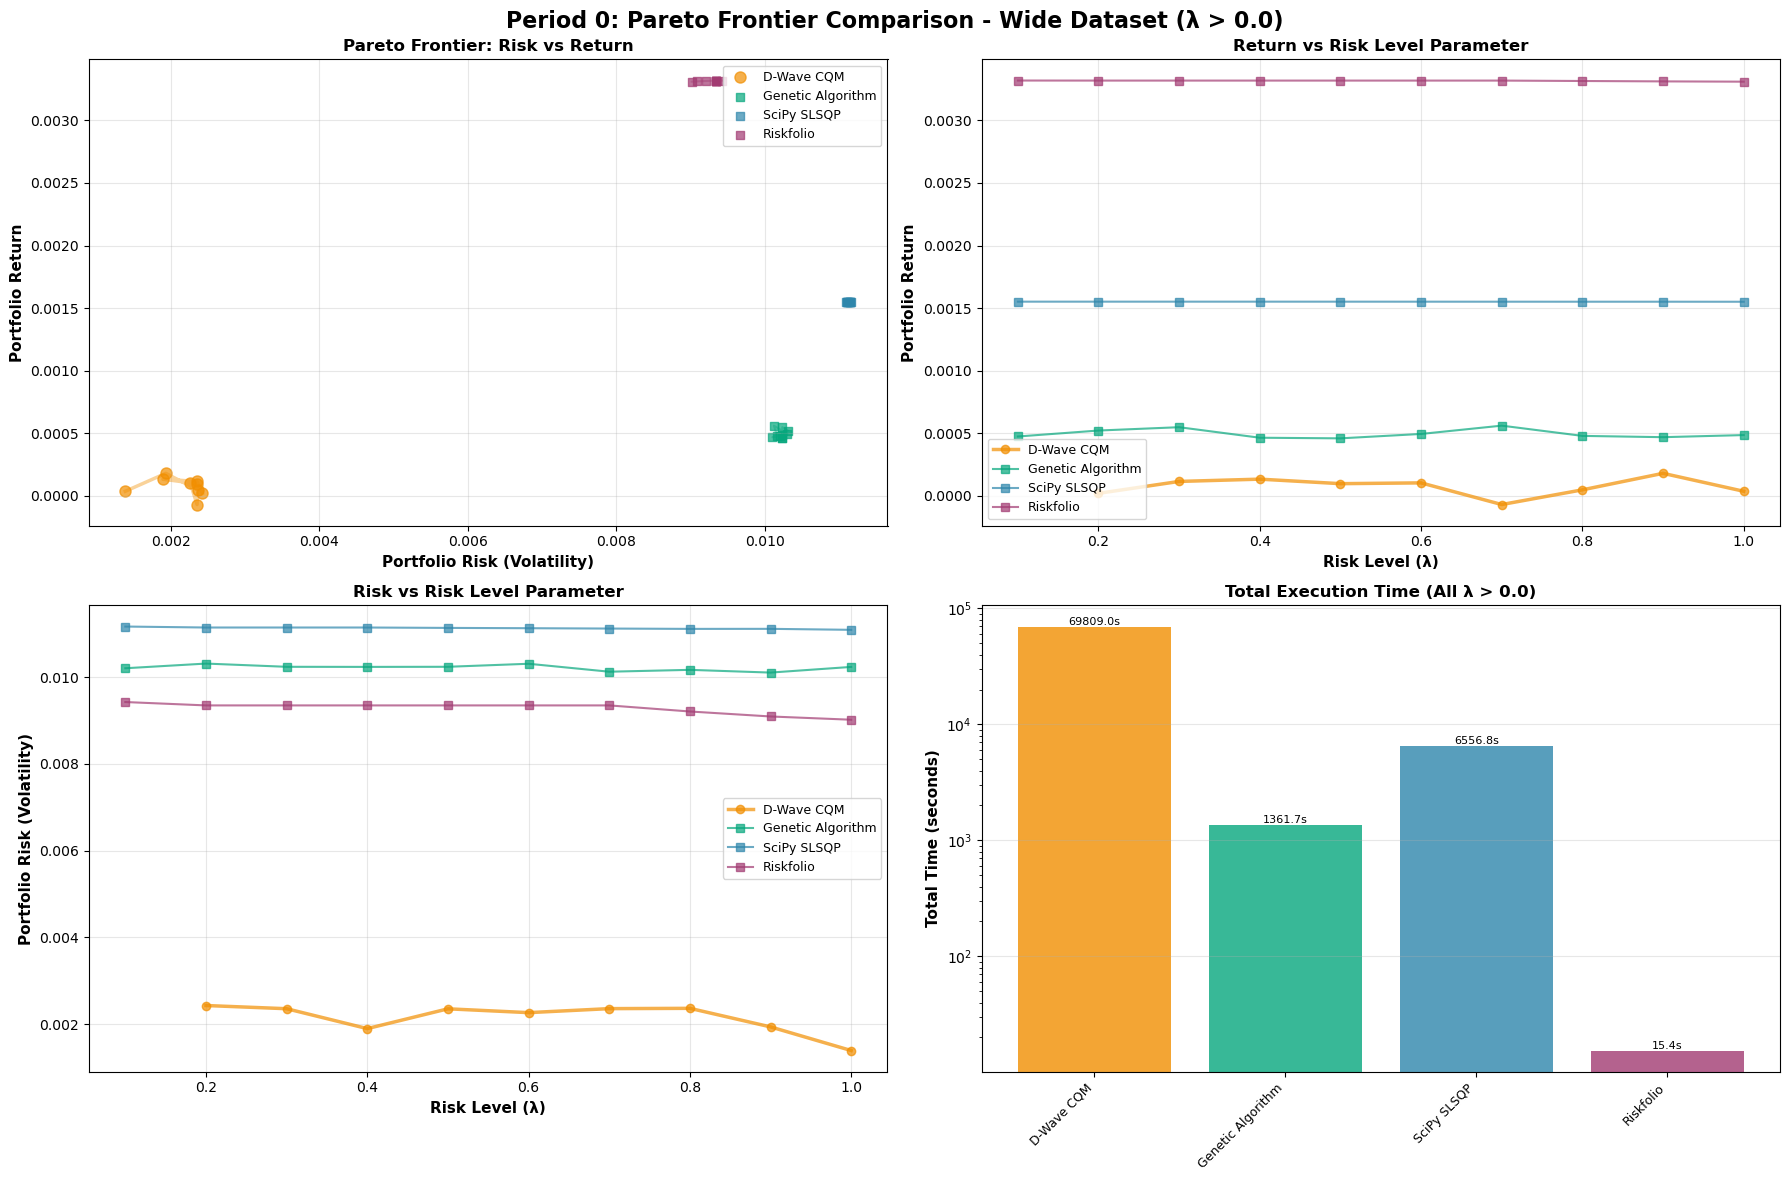


DETAILED PARETO ANALYSIS - Period 0
----------------------------------------------------------------------------------------------------

D-Wave CQM:
  Valid lambda values: 9/10
  Pareto-optimal points: 3
  Average return: 0.000075
  Average risk: 0.002148
  Average Sharpe ratio: 0.0364
  Total execution time: 69808.99s

Genetic Algorithm:
  Valid lambda values: 10/10
  Pareto-optimal points: 2
  Average return: 0.000496
  Average risk: 0.010218
  Average Sharpe ratio: 0.0486
  Total execution time: 1361.74s

SciPy SLSQP:
  Valid lambda values: 10/10
  Pareto-optimal points: 7
  Average return: 0.001552
  Average risk: 0.011130
  Average Sharpe ratio: 0.1394
  Total execution time: 6556.84s

Riskfolio:
  Valid lambda values: 10/10
  Pareto-optimal points: 6
  Average return: 0.003316
  Average risk: 0.009283
  Average Sharpe ratio: 0.3573
  Total execution time: 15.43s



In [ ]:
# Load all available Pareto results across all time periods for comparison
import os
import glob
import re

print("Discovering all available time periods for Pareto comparison...")
print("="*100)

results_base_dir = '../../results/pareto_optimization/'

# Find all D-Wave Pareto results to determine available periods
dwave_pattern = os.path.join(results_base_dir, 'pareto_wide_dwave_cqm_lambda_*_period_*.pkl')
dwave_files = glob.glob(dwave_pattern)

# Extract period numbers from D-Wave results
available_periods = set()
for f in dwave_files:
    match = re.search(r'pareto_wide_dwave_cqm_lambda_\d+_period_(\d+)\.pkl$', f)
    if match:
        available_periods.add(int(match.group(1)))

available_periods = sorted(list(available_periods))

if len(available_periods) == 0:
    print("✗ No D-Wave Pareto results found. Run the D-Wave optimization first.")
else:
    print(f"✓ Found D-Wave Pareto results for {len(available_periods)} period(s): {available_periods}")
    
    # Load results for all available periods
    all_periods_pareto_data = {}
    
    for period in available_periods:
        period_data = {}
        
        # Load D-Wave results from individual lambda files
        dwave_results = {}
        for risk_level in parameters['risk_levels']:
            if risk_level == 0.0:  # Skip lambda = 0.0
                continue
            lambda_str = str(risk_level).replace('.', '')
            dwave_path = f'../../results/pareto_optimization/pareto_wide_dwave_cqm_lambda_{lambda_str}_period_{period}.pkl'
            if os.path.exists(dwave_path):
                result = read_pickle_dict(dwave_path)
                # D-Wave checkpoints have the correct structure already
                if result is not None and 'portfolio_return' in result:
                    dwave_results[risk_level] = result
        
        if dwave_results:
            period_data['D-Wave CQM'] = dwave_results
            print(f"  D-Wave CQM: {len(dwave_results)} lambda values loaded")
        
        # Load classical solver Pareto results
        solver_prefixes = {
            'Genetic Algorithm': 'ga',
            'SciPy SLSQP': 'slsqp',
            'Riskfolio': 'riskfolio',
        }
        
        for solver_name, prefix in solver_prefixes.items():
            path = f'../../results/pareto_optimization/pareto_wide_{prefix}_period_{period}.pkl'
            if os.path.exists(path):
                solver_results = read_pickle_dict(path)
                if solver_results is not None:
                    # Filter out lambda = 0.0 for classical solvers too
                    filtered_results = {k: v for k, v in solver_results.items() if k != 0.0 and v is not None}
                    if filtered_results:
                        period_data[solver_name] = filtered_results
                        print(f"  {solver_name}: {len(filtered_results)} lambda values loaded")
        
        all_periods_pareto_data[period] = period_data
    
    print("="*100)
    
    # Create comprehensive Pareto frontier comparison for each period
    for period in available_periods:
        results_dict = all_periods_pareto_data[period]
        
        if len(results_dict) == 0:
            print(f"\n⚠️  No results available for period {period}")
            continue
        
        print(f"\n{'='*100}")
        print(f"PERIOD {period} - PARETO FRONTIER COMPARATIVE ANALYSIS (λ > 0.0)")
        print(f"{'='*100}")
        
        # Plot Pareto frontier comparison
        fig, axes = plt.subplots(2, 2, figsize=(18, 12))
        fig.suptitle(f'Period {period}: Pareto Frontier Comparison - Wide Dataset (λ > 0.0)', 
                     fontsize=16, fontweight='bold')
        
        # Define color scheme
        colors = {
            'D-Wave CQM': '#F18F01',
            'Genetic Algorithm': '#06A77D',
            'SciPy SLSQP': '#2E86AB',
            'Riskfolio': '#A23B72'
        }
        
        # Plot 1: Risk-Return Pareto Frontier
        ax1 = axes[0, 0]
        for solver_name, solver_results in results_dict.items():
            valid_points = []
            for r in solver_results.values():
                if r is not None and 'portfolio_risk' in r and 'portfolio_return' in r:
                    valid_points.append((r['portfolio_risk'], r['portfolio_return']))
            
            if valid_points:
                risks, returns = zip(*valid_points)
                color = colors.get(solver_name, '#333333')
                linewidth = 2.5 if solver_name == 'D-Wave CQM' else 1.5
                marker = 'o' if solver_name == 'D-Wave CQM' else 's'
                markersize = 8 if solver_name == 'D-Wave CQM' else 6
                ax1.scatter(risks, returns, label=solver_name, 
                           color=color, s=markersize**2, marker=marker, alpha=0.7)
                ax1.plot(risks, returns, color=color, linewidth=linewidth, alpha=0.4)
        
        ax1.set_xlabel('Portfolio Risk (Volatility)', fontsize=11, fontweight='bold')
        ax1.set_ylabel('Portfolio Return', fontsize=11, fontweight='bold')
        ax1.set_title('Pareto Frontier: Risk vs Return', fontsize=12, fontweight='bold')
        ax1.legend(loc='best', fontsize=9)
        ax1.grid(True, alpha=0.3)
        
        # Plot 2: Lambda vs Return
        ax2 = axes[0, 1]
        for solver_name, solver_results in results_dict.items():
            lambdas = []
            returns = []
            for risk_level, result in solver_results.items():
                if result is not None and 'portfolio_return' in result:
                    lambdas.append(risk_level)
                    returns.append(result['portfolio_return'])
            
            if lambdas:
                color = colors.get(solver_name, '#333333')
                linewidth = 2.5 if solver_name == 'D-Wave CQM' else 1.5
                marker = 'o' if solver_name == 'D-Wave CQM' else 's'
                ax2.plot(lambdas, returns, label=solver_name, 
                        color=color, linewidth=linewidth, marker=marker, markersize=6, alpha=0.7)
        
        ax2.set_xlabel('Risk Level (λ)', fontsize=11, fontweight='bold')
        ax2.set_ylabel('Portfolio Return', fontsize=11, fontweight='bold')
        ax2.set_title('Return vs Risk Level Parameter', fontsize=12, fontweight='bold')
        ax2.legend(loc='best', fontsize=9)
        ax2.grid(True, alpha=0.3)
        
        # Plot 3: Lambda vs Risk
        ax3 = axes[1, 0]
        for solver_name, solver_results in results_dict.items():
            lambdas = []
            risks = []
            for risk_level, result in solver_results.items():
                if result is not None and 'portfolio_risk' in result:
                    lambdas.append(risk_level)
                    risks.append(result['portfolio_risk'])
            
            if lambdas:
                color = colors.get(solver_name, '#333333')
                linewidth = 2.5 if solver_name == 'D-Wave CQM' else 1.5
                marker = 'o' if solver_name == 'D-Wave CQM' else 's'
                ax3.plot(lambdas, risks, label=solver_name, 
                        color=color, linewidth=linewidth, marker=marker, markersize=6, alpha=0.7)
        
        ax3.set_xlabel('Risk Level (λ)', fontsize=11, fontweight='bold')
        ax3.set_ylabel('Portfolio Risk (Volatility)', fontsize=11, fontweight='bold')
        ax3.set_title('Risk vs Risk Level Parameter', fontsize=12, fontweight='bold')
        ax3.legend(loc='best', fontsize=9)
        ax3.grid(True, alpha=0.3)
        
        # Plot 4: Execution Time Comparison
        ax4 = axes[1, 1]
        exec_times = []
        solver_names_list = []
        time_colors = []
        
        for solver_name, solver_results in results_dict.items():
            valid_results = [r for r in solver_results.values() 
                           if r is not None and 'execution_time' in r]
            if valid_results:
                total_time = sum(r['execution_time'] for r in valid_results)
                exec_times.append(total_time)
                solver_names_list.append(solver_name)
                time_colors.append(colors.get(solver_name, '#333333'))
        
        if exec_times:
            bars = ax4.bar(range(len(exec_times)), exec_times, color=time_colors, alpha=0.8)
            ax4.set_xticks(range(len(solver_names_list)))
            ax4.set_xticklabels(solver_names_list, rotation=45, ha='right', fontsize=9)
            ax4.set_ylabel('Total Time (seconds)', fontsize=11, fontweight='bold')
            ax4.set_title('Total Execution Time (All λ > 0.0)', fontsize=12, fontweight='bold')
            ax4.set_yscale('log')
            ax4.grid(True, axis='y', alpha=0.3)
            
            # Add value labels on bars
            for i, (bar, value) in enumerate(zip(bars, exec_times)):
                height = bar.get_height()
                ax4.text(bar.get_x() + bar.get_width()/2., height,
                        f'{value:.1f}s', ha='center', va='bottom', fontsize=8)
        
        plt.tight_layout()
        plt.show()
        
        # Print detailed comparison for this period
        print(f"\nDETAILED PARETO ANALYSIS - Period {period}")
        print("-" * 100)
        
        for solver_name, solver_results in results_dict.items():
            valid_results = [r for r in solver_results.values() 
                           if r is not None and 'portfolio_return' in r]
            pareto_points = extract_pareto_frontier(solver_results)
            
            if valid_results:
                avg_return = np.mean([r['portfolio_return'] for r in valid_results])
                avg_risk = np.mean([r['portfolio_risk'] for r in valid_results])
                avg_sharpe = np.mean([r['sharpe_ratio'] for r in valid_results])
                total_time = sum(r.get('execution_time', 0) for r in valid_results)
                
                print(f"\n{solver_name}:")
                print(f"  Valid lambda values: {len(valid_results)}/{len([x for x in parameters['risk_levels'] if x != 0.0])}")
                print(f"  Pareto-optimal points: {len(pareto_points)}")
                print(f"  Average return: {avg_return:.6f}")
                print(f"  Average risk: {avg_risk:.6f}")
                print(f"  Average Sharpe ratio: {avg_sharpe:.4f}")
                print(f"  Total execution time: {total_time:.2f}s")
    
    print(f"\n{'='*100}")

## Normalized Pareto Frontier Comparison

Compare the shape of efficient frontiers by normalizing risk and return values to [0, 1] range for each solver.

Normalized Pareto Frontier Shape Comparison

PERIOD 0 - NORMALIZED SHAPE COMPARISON (λ > 0.0)

D-Wave CQM:
  Original Risk range: [0.001389, 0.002428]
  Original Return range: [-0.000069, 0.000181]

Genetic Algorithm:
  Original Risk range: [0.010105, 0.010313]
  Original Return range: [0.000460, 0.000561]

SciPy SLSQP:
  Original Risk range: [0.011091, 0.011167]
  Original Return range: [0.001551, 0.001552]

Riskfolio:
  Original Risk range: [0.009018, 0.009426]
  Original Return range: [0.003309, 0.003318]


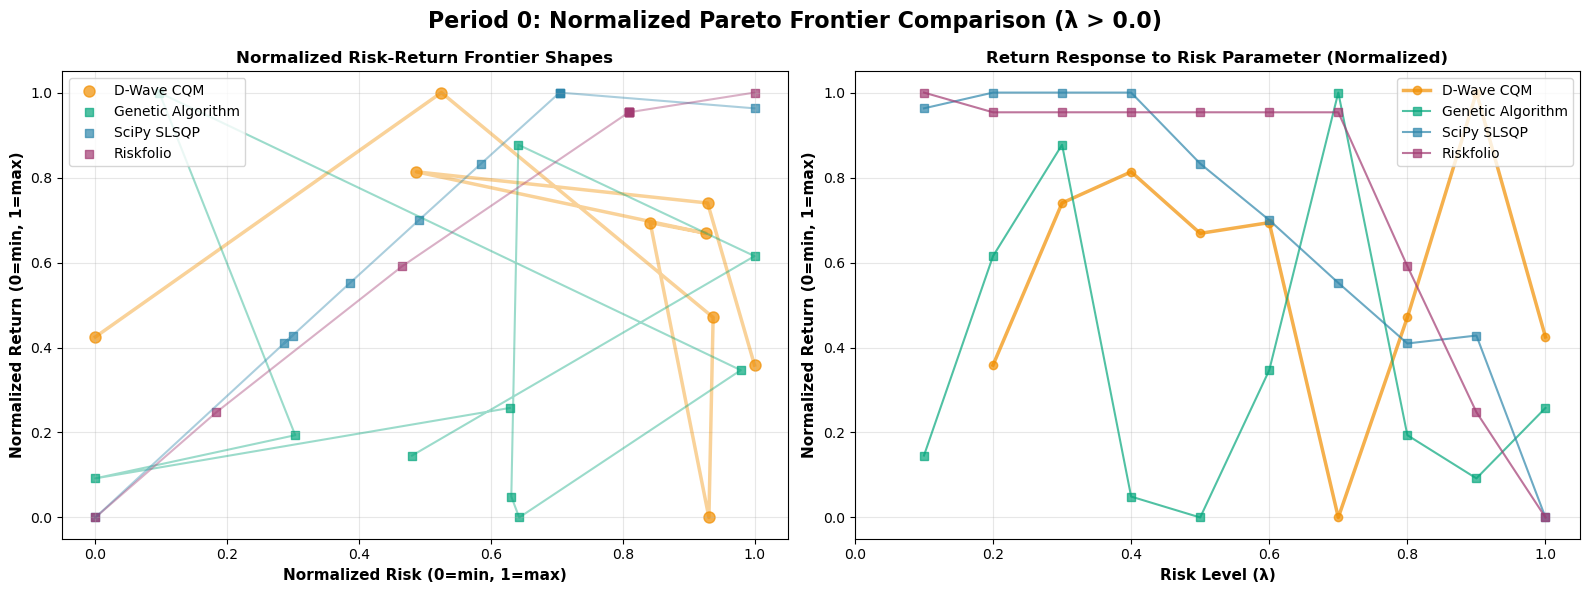

In [ ]:
# Normalized Pareto Frontier Shape Comparison
import os
import glob
import re

print("Normalized Pareto Frontier Shape Comparison")
print("="*100)

results_base_dir = '../../results/pareto_optimization/'

# Find all D-Wave Pareto results to determine available periods
dwave_pattern = os.path.join(results_base_dir, 'pareto_wide_dwave_cqm_lambda_*_period_*.pkl')
dwave_files = glob.glob(dwave_pattern)

# Extract period numbers from D-Wave results
available_periods = set()
for f in dwave_files:
    match = re.search(r'pareto_wide_dwave_cqm_lambda_\d+_period_(\d+)\.pkl$', f)
    if match:
        available_periods.add(int(match.group(1)))

available_periods = sorted(list(available_periods))

if len(available_periods) == 0:
    print("✗ No D-Wave Pareto results found. Run the D-Wave optimization first.")
else:
    # Load results for all available periods
    all_periods_pareto_data = {}
    
    for period in available_periods:
        period_data = {}
        
        # Load D-Wave results from individual lambda files
        dwave_results = {}
        for risk_level in parameters['risk_levels']:
            if risk_level == 0.0:  # Skip lambda = 0.0
                continue
            lambda_str = str(risk_level).replace('.', '')
            dwave_path = f'../../results/pareto_optimization/pareto_wide_dwave_cqm_lambda_{lambda_str}_period_{period}.pkl'
            if os.path.exists(dwave_path):
                result = read_pickle_dict(dwave_path)
                if result is not None and 'portfolio_return' in result:
                    dwave_results[risk_level] = result
        
        if dwave_results:
            period_data['D-Wave CQM'] = dwave_results
        
        # Load classical solver Pareto results
        solver_prefixes = {
            'Genetic Algorithm': 'ga',
            'SciPy SLSQP': 'slsqp',
            'Riskfolio': 'riskfolio',
        }
        
        for solver_name, prefix in solver_prefixes.items():
            path = f'../../results/pareto_optimization/pareto_wide_{prefix}_period_{period}.pkl'
            if os.path.exists(path):
                solver_results = read_pickle_dict(path)
                if solver_results is not None:
                    filtered_results = {k: v for k, v in solver_results.items() if k != 0.0 and v is not None}
                    if filtered_results:
                        period_data[solver_name] = filtered_results
        
        all_periods_pareto_data[period] = period_data
    
    # Create normalized shape comparison for each period
    for period in available_periods:
        results_dict = all_periods_pareto_data[period]
        
        if len(results_dict) == 0:
            print(f"\n⚠️  No results available for period {period}")
            continue
        
        print(f"\n{'='*100}")
        print(f"PERIOD {period} - NORMALIZED SHAPE COMPARISON (λ > 0.0)")
        print(f"{'='*100}")
        
        # Define color scheme
        colors = {
            'D-Wave CQM': '#F18F01',
            'Genetic Algorithm': '#06A77D',
            'SciPy SLSQP': '#2E86AB',
            'Riskfolio': '#A23B72'
        }
        
        # Create figure with normalized frontiers
        fig, axes = plt.subplots(1, 2, figsize=(16, 6))
        fig.suptitle(f'Period {period}: Normalized Pareto Frontier Comparison (λ > 0.0)', 
                     fontsize=16, fontweight='bold')
        
        # Plot 1: Normalized Risk-Return Space
        ax1 = axes[0]
        
        for solver_name, solver_results in results_dict.items():
            # Extract valid risk-return points
            risks = []
            returns = []
            for r in solver_results.values():
                if r is not None and 'portfolio_risk' in r and 'portfolio_return' in r:
                    risks.append(r['portfolio_risk'])
                    returns.append(r['portfolio_return'])
            
            if len(risks) > 1:
                # Normalize to [0, 1] range
                risk_min, risk_max = min(risks), max(risks)
                return_min, return_max = min(returns), max(returns)
                
                # Avoid division by zero
                risk_range = risk_max - risk_min if risk_max != risk_min else 1
                return_range = return_max - return_min if return_max != return_min else 1
                
                normalized_risks = [(r - risk_min) / risk_range for r in risks]
                normalized_returns = [(ret - return_min) / return_range for ret in returns]
                
                color = colors.get(solver_name, '#333333')
                linewidth = 2.5 if solver_name == 'D-Wave CQM' else 1.5
                marker = 'o' if solver_name == 'D-Wave CQM' else 's'
                markersize = 8 if solver_name == 'D-Wave CQM' else 6
                
                ax1.scatter(normalized_risks, normalized_returns, label=solver_name, 
                           color=color, s=markersize**2, marker=marker, alpha=0.7)
                ax1.plot(normalized_risks, normalized_returns, color=color, 
                        linewidth=linewidth, alpha=0.4)
                
                print(f"\n{solver_name}:")
                print(f"  Original Risk range: [{risk_min:.6f}, {risk_max:.6f}]")
                print(f"  Original Return range: [{return_min:.6f}, {return_max:.6f}]")
        
        ax1.set_xlabel('Normalized Risk (0=min, 1=max)', fontsize=11, fontweight='bold')
        ax1.set_ylabel('Normalized Return (0=min, 1=max)', fontsize=11, fontweight='bold')
        ax1.set_title('Normalized Risk-Return Frontier Shapes', fontsize=12, fontweight='bold')
        ax1.legend(loc='best', fontsize=10)
        ax1.grid(True, alpha=0.3)
        ax1.set_xlim(-0.05, 1.05)
        ax1.set_ylim(-0.05, 1.05)
        
        # Plot 2: Normalized Lambda Response
        ax2 = axes[1]
        
        for solver_name, solver_results in results_dict.items():
            lambdas = []
            returns = []
            
            for risk_level, result in sorted(solver_results.items()):
                if result is not None and 'portfolio_return' in result:
                    lambdas.append(risk_level)
                    returns.append(result['portfolio_return'])
            
            if len(returns) > 1:
                # Normalize returns to [0, 1]
                return_min, return_max = min(returns), max(returns)
                return_range = return_max - return_min if return_max != return_min else 1
                normalized_returns = [(ret - return_min) / return_range for ret in returns]
                
                color = colors.get(solver_name, '#333333')
                linewidth = 2.5 if solver_name == 'D-Wave CQM' else 1.5
                marker = 'o' if solver_name == 'D-Wave CQM' else 's'
                
                ax2.plot(lambdas, normalized_returns, label=solver_name, 
                        color=color, linewidth=linewidth, marker=marker, markersize=6, alpha=0.7)
        
        ax2.set_xlabel('Risk Level (λ)', fontsize=11, fontweight='bold')
        ax2.set_ylabel('Normalized Return (0=min, 1=max)', fontsize=11, fontweight='bold')
        ax2.set_title('Return Response to Risk Parameter (Normalized)', fontsize=12, fontweight='bold')
        ax2.legend(loc='best', fontsize=10)
        ax2.grid(True, alpha=0.3)
        ax2.set_xlim(0, 1.05)
        ax2.set_ylim(-0.05, 1.05)
        
        plt.tight_layout()
        plt.show()
    
    print(f"\n{'='*100}")

## Sharpe Ratio Comparison

Compare solvers using Sharpe ratios (risk-adjusted returns) across different lambda values.

Sharpe Ratio Comparison Across Solvers

PERIOD 0 - SHARPE RATIO COMPARISON (λ > 0.0)


/tmp/ipykernel_409543/3664703460.py:208: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax4.boxplot(sharpe_data, labels=sharpe_labels, patch_artist=True,


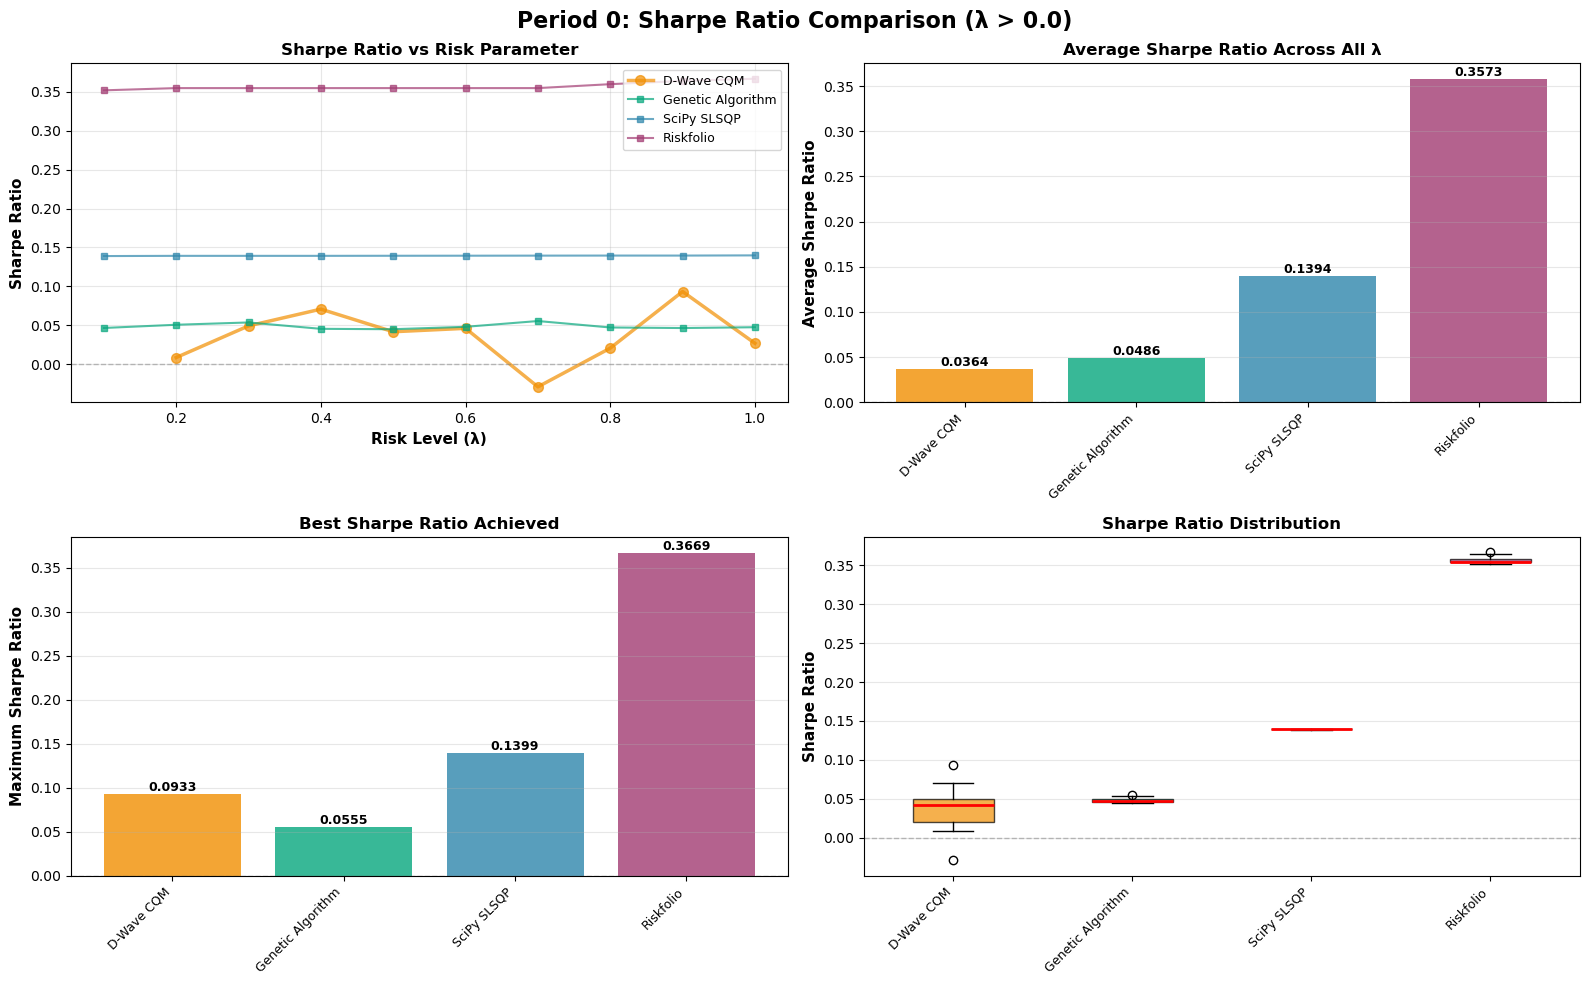


DETAILED SHARPE RATIO STATISTICS - Period 0
----------------------------------------------------------------------------------------------------

D-Wave CQM:
  Count: 9
  Mean: 0.036425
  Std Dev: 0.033536
  Min: -0.029144
  Max: 0.093341
  Median: 0.041672
  Positive count: 8/9

Genetic Algorithm:
  Count: 10
  Mean: 0.048574
  Std Dev: 0.003355
  Min: 0.044925
  Max: 0.055451
  Median: 0.047332
  Positive count: 10/10

SciPy SLSQP:
  Count: 10
  Mean: 0.139410
  Std Dev: 0.000236
  Min: 0.138970
  Max: 0.139853
  Median: 0.139394
  Positive count: 10/10

Riskfolio:
  Count: 10
  Mean: 0.357253
  Std Dev: 0.004573
  Min: 0.352024
  Max: 0.366938
  Median: 0.354908
  Positive count: 10/10



In [ ]:
# Sharpe Ratio Comparison
import os
import glob
import re

print("Sharpe Ratio Comparison Across Solvers")
print("="*100)

results_base_dir = '../../results/pareto_optimization/'

# Find all D-Wave Pareto results to determine available periods
dwave_pattern = os.path.join(results_base_dir, 'pareto_wide_dwave_cqm_lambda_*_period_*.pkl')
dwave_files = glob.glob(dwave_pattern)

# Extract period numbers from D-Wave results
available_periods = set()
for f in dwave_files:
    match = re.search(r'pareto_wide_dwave_cqm_lambda_\d+_period_(\d+)\.pkl$', f)
    if match:
        available_periods.add(int(match.group(1)))

available_periods = sorted(list(available_periods))

if len(available_periods) == 0:
    print("✗ No D-Wave Pareto results found. Run the D-Wave optimization first.")
else:
    # Load results for all available periods
    all_periods_pareto_data = {}
    
    for period in available_periods:
        period_data = {}
        
        # Load D-Wave results from individual lambda files
        dwave_results = {}
        for risk_level in parameters['risk_levels']:
            if risk_level == 0.0:  # Skip lambda = 0.0
                continue
            lambda_str = str(risk_level).replace('.', '')
            dwave_path = f'../../results/pareto_optimization/pareto_wide_dwave_cqm_lambda_{lambda_str}_period_{period}.pkl'
            if os.path.exists(dwave_path):
                result = read_pickle_dict(dwave_path)
                if result is not None and 'portfolio_return' in result:
                    dwave_results[risk_level] = result
        
        if dwave_results:
            period_data['D-Wave CQM'] = dwave_results
        
        # Load classical solver Pareto results
        solver_prefixes = {
            'Genetic Algorithm': 'ga',
            'SciPy SLSQP': 'slsqp',
            'Riskfolio': 'riskfolio',
        }
        
        for solver_name, prefix in solver_prefixes.items():
            path = f'../../results/pareto_optimization/pareto_wide_{prefix}_period_{period}.pkl'
            if os.path.exists(path):
                solver_results = read_pickle_dict(path)
                if solver_results is not None:
                    filtered_results = {k: v for k, v in solver_results.items() if k != 0.0 and v is not None}
                    if filtered_results:
                        period_data[solver_name] = filtered_results
        
        all_periods_pareto_data[period] = period_data
    
    # Create Sharpe ratio comparison for each period
    for period in available_periods:
        results_dict = all_periods_pareto_data[period]
        
        if len(results_dict) == 0:
            print(f"\n⚠️  No results available for period {period}")
            continue
        
        print(f"\n{'='*100}")
        print(f"PERIOD {period} - SHARPE RATIO COMPARISON (λ > 0.0)")
        print(f"{'='*100}")
        
        # Define color scheme
        colors = {
            'D-Wave CQM': '#F18F01',
            'Genetic Algorithm': '#06A77D',
            'SciPy SLSQP': '#2E86AB',
            'Riskfolio': '#A23B72'
        }
        
        # Create figure with Sharpe ratio comparisons
        fig, axes = plt.subplots(2, 2, figsize=(16, 10))
        fig.suptitle(f'Period {period}: Sharpe Ratio Comparison (λ > 0.0)', 
                     fontsize=16, fontweight='bold')
        
        # Plot 1: Sharpe Ratio vs Lambda
        ax1 = axes[0, 0]
        
        for solver_name, solver_results in results_dict.items():
            lambdas = []
            sharpes = []
            
            for risk_level, result in sorted(solver_results.items()):
                if result is not None and 'sharpe_ratio' in result:
                    lambdas.append(risk_level)
                    sharpes.append(result['sharpe_ratio'])
            
            if lambdas:
                color = colors.get(solver_name, '#333333')
                linewidth = 2.5 if solver_name == 'D-Wave CQM' else 1.5
                marker = 'o' if solver_name == 'D-Wave CQM' else 's'
                markersize = 7 if solver_name == 'D-Wave CQM' else 5
                
                ax1.plot(lambdas, sharpes, label=solver_name, 
                        color=color, linewidth=linewidth, marker=marker, markersize=markersize, alpha=0.7)
        
        ax1.set_xlabel('Risk Level (λ)', fontsize=11, fontweight='bold')
        ax1.set_ylabel('Sharpe Ratio', fontsize=11, fontweight='bold')
        ax1.set_title('Sharpe Ratio vs Risk Parameter', fontsize=12, fontweight='bold')
        ax1.legend(loc='best', fontsize=9)
        ax1.grid(True, alpha=0.3)
        ax1.axhline(y=0, color='gray', linestyle='--', linewidth=1, alpha=0.5)
        
        # Plot 2: Average Sharpe Ratio by Solver
        ax2 = axes[0, 1]
        
        avg_sharpes = []
        solver_names_list = []
        bar_colors = []
        
        for solver_name, solver_results in results_dict.items():
            sharpes = []
            for result in solver_results.values():
                if result is not None and 'sharpe_ratio' in result:
                    sharpes.append(result['sharpe_ratio'])
            
            if sharpes:
                avg_sharpes.append(np.mean(sharpes))
                solver_names_list.append(solver_name)
                bar_colors.append(colors.get(solver_name, '#333333'))
        
        if avg_sharpes:
            bars = ax2.bar(range(len(avg_sharpes)), avg_sharpes, color=bar_colors, alpha=0.8)
            ax2.set_xticks(range(len(solver_names_list)))
            ax2.set_xticklabels(solver_names_list, rotation=45, ha='right', fontsize=9)
            ax2.set_ylabel('Average Sharpe Ratio', fontsize=11, fontweight='bold')
            ax2.set_title('Average Sharpe Ratio Across All λ', fontsize=12, fontweight='bold')
            ax2.grid(True, axis='y', alpha=0.3)
            ax2.axhline(y=0, color='gray', linestyle='--', linewidth=1, alpha=0.5)
            
            # Add value labels on bars
            for bar, value in zip(bars, avg_sharpes):
                height = bar.get_height()
                y_pos = height if height > 0 else 0
                va = 'bottom' if height > 0 else 'top'
                ax2.text(bar.get_x() + bar.get_width()/2., y_pos,
                        f'{value:.4f}', ha='center', va=va, fontsize=9, fontweight='bold')
        
        # Plot 3: Best Sharpe Ratio by Solver
        ax3 = axes[1, 0]
        
        max_sharpes = []
        solver_names_list2 = []
        bar_colors2 = []
        
        for solver_name, solver_results in results_dict.items():
            sharpes = []
            for result in solver_results.values():
                if result is not None and 'sharpe_ratio' in result:
                    sharpes.append(result['sharpe_ratio'])
            
            if sharpes:
                max_sharpes.append(max(sharpes))
                solver_names_list2.append(solver_name)
                bar_colors2.append(colors.get(solver_name, '#333333'))
        
        if max_sharpes:
            bars = ax3.bar(range(len(max_sharpes)), max_sharpes, color=bar_colors2, alpha=0.8)
            ax3.set_xticks(range(len(solver_names_list2)))
            ax3.set_xticklabels(solver_names_list2, rotation=45, ha='right', fontsize=9)
            ax3.set_ylabel('Maximum Sharpe Ratio', fontsize=11, fontweight='bold')
            ax3.set_title('Best Sharpe Ratio Achieved', fontsize=12, fontweight='bold')
            ax3.grid(True, axis='y', alpha=0.3)
            ax3.axhline(y=0, color='gray', linestyle='--', linewidth=1, alpha=0.5)
            
            # Add value labels on bars
            for bar, value in zip(bars, max_sharpes):
                height = bar.get_height()
                y_pos = height if height > 0 else 0
                va = 'bottom' if height > 0 else 'top'
                ax3.text(bar.get_x() + bar.get_width()/2., y_pos,
                        f'{value:.4f}', ha='center', va=va, fontsize=9, fontweight='bold')
        
        # Plot 4: Sharpe Ratio Distribution (Box Plot)
        ax4 = axes[1, 1]
        
        sharpe_data = []
        sharpe_labels = []
        sharpe_colors_list = []
        
        for solver_name, solver_results in results_dict.items():
            sharpes = []
            for result in solver_results.values():
                if result is not None and 'sharpe_ratio' in result:
                    sharpes.append(result['sharpe_ratio'])
            
            if sharpes:
                sharpe_data.append(sharpes)
                sharpe_labels.append(solver_name)
                sharpe_colors_list.append(colors.get(solver_name, '#333333'))
        
        if sharpe_data:
            bp = ax4.boxplot(sharpe_data, labels=sharpe_labels, patch_artist=True,
                            medianprops=dict(color='red', linewidth=2),
                            boxprops=dict(alpha=0.7))
            
            # Color the boxes
            for patch, color in zip(bp['boxes'], sharpe_colors_list):
                patch.set_facecolor(color)
            
            ax4.set_xticklabels(sharpe_labels, rotation=45, ha='right', fontsize=9)
            ax4.set_ylabel('Sharpe Ratio', fontsize=11, fontweight='bold')
            ax4.set_title('Sharpe Ratio Distribution', fontsize=12, fontweight='bold')
            ax4.grid(True, axis='y', alpha=0.3)
            ax4.axhline(y=0, color='gray', linestyle='--', linewidth=1, alpha=0.5)
        
        plt.tight_layout()
        plt.show()
        
        # Print detailed Sharpe ratio statistics
        print(f"\nDETAILED SHARPE RATIO STATISTICS - Period {period}")
        print("-" * 100)
        
        for solver_name, solver_results in results_dict.items():
            sharpes = []
            for result in solver_results.values():
                if result is not None and 'sharpe_ratio' in result:
                    sharpes.append(result['sharpe_ratio'])
            
            if sharpes:
                print(f"\n{solver_name}:")
                print(f"  Count: {len(sharpes)}")
                print(f"  Mean: {np.mean(sharpes):.6f}")
                print(f"  Std Dev: {np.std(sharpes):.6f}")
                print(f"  Min: {np.min(sharpes):.6f}")
                print(f"  Max: {np.max(sharpes):.6f}")
                print(f"  Median: {np.median(sharpes):.6f}")
                print(f"  Positive count: {sum(1 for s in sharpes if s > 0)}/{len(sharpes)}")
    
    print(f"\n{'='*100}")

## Weight Constraint Update

**IMPORTANT:** The classical solver weight constraints have been updated to match D-Wave CQM behavior:

```python
# Updated in optimization_engines.py:
max_weight = 0.30  # 30% per asset (was: 1.47%)
min_weight = 0.001 # 0.1% per asset (unchanged)
```

### Rationale:

D-Wave CQM analysis showed:
- Maximum weight used: **28.62%**
- Average maximum: **21.42%**
- Top 5 concentration: **59.7%**

Setting `max_weight = 0.30` allows classical solvers to:
- ✅ Explore similar concentration levels as D-Wave
- ✅ Respond meaningfully to lambda parameter
- ✅ Create proper efficient frontiers instead of scattered points
- ✅ Maintain all 680 accounts funded (capital allocation requirement)

**You must re-run the classical solver optimizations** (GA, SciPy, Riskfolio) with the new constraints. D-Wave results remain unchanged.